# 04 — Modelo CBOW y entrenamiento (Fases 4 y 5)

Prueba interactiva de `src/model.py`. Se valida:

1. La arquitectura y **por qué hay dos matrices de embeddings**.
2. Un forward pass completo con un batch real, **verificando las dimensiones de
   cada tensor** en cada paso.
3. Que el **promedio enmascarado** sea correcto, comparándolo con la cuenta
   hecha a mano.
4. Que el **muestreador de negativos** siga la distribución unigrama^0,75.
5. Que la **loss inicial** valga exactamente `(1+K)·ln 2`.
6. Que el modelo **pueda aprender**: test de sobreajuste sobre un batch fijo.
7. Cuánto ahorra el negative sampling frente al softmax completo.

Y de la Fase 5 (`src/train.py`):

8. El **loop de entrenamiento**: épocas, checkpoints y curva de loss.
9. Los resultados reales de la corrida piloto sobre 2M de oraciones.

In [1]:
import math
import sys
import time
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.config import corpus_path, load_config, vocab_path
from src.dataset import CBOWIterableDataset, format_pair
from src.model import CBOWModel, NegativeSampler, build_model_from_config, masked_mean
from src.vocabulary import Vocabulary

CONFIG = load_config("configs/piloto_5k_50_2.yaml")
VOCAB = Vocabulary.load(vocab_path(CONFIG))
C = CONFIG["context_size"]
D = CONFIG["embedding_dim"]
K = CONFIG["negative_samples"]
B = CONFIG["batch_size"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("config          :", CONFIG["name"])
print("vocab prestado  :", vocab_path(CONFIG).parent.name, "|", VOCAB)
print(f"embedding_dim D : {D}")
print(f"context_size C  : {C}   (contexto de ancho 2C = {2 * C})")
print(f"negativos K     : {K}")
print(f"batch_size B    : {B}")
print("dispositivo     :", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

config          : piloto_5k_50_2
vocab prestado  : base_5k_50_2 | Vocabulary(size=5000, total_tokens=2,028,209,650, coverage=0.8326, min_count=5)
embedding_dim D : 50
context_size C  : 2   (contexto de ancho 2C = 4)
negativos K     : 10
batch_size B    : 512
dispositivo     : cuda | NVIDIA GeForce RTX 3060 Laptop GPU


## 1. Dos matrices de embeddings, no una

Es la parte menos intuitiva de CBOW. Cada palabra tiene **dos** vectores:

| Matriz | Rol | Destino |
|---|---|---|
| `input_embeddings` | la palabra **como contexto** | se exporta: son "los embeddings" |
| `output_embeddings` | la palabra **como target** | se descarta al terminar |

¿Por qué? Porque el modelo aprende a predecir el target *a partir del* contexto,
y son roles asimétricos. Si se usara una sola matriz, el producto punto de una
palabra consigo misma aparecería en la loss y el modelo tendería a degenerar.
Es lo que hace el word2vec original.

In [2]:
model, sampler = build_model_from_config(CONFIG, VOCAB)
model.to(DEVICE)
sampler.to(DEVICE)

print(model)
print(sampler)
print()
print(f"{'tensor':<24} {'forma':<16} {'parámetros':>12}")
print("-" * 56)
for nombre, p in model.named_parameters():
    print(f"{nombre:<24} {str(tuple(p.shape)):<16} {p.numel():>12,}")
print("-" * 56)
print(f"{'TOTAL':<24} {'':<16} {model.n_parameters():>12,}")
print()
print(f"Comprobación: 2 matrices × {len(VOCAB):,} palabras × {D} dimensiones "
      f"= {2 * len(VOCAB) * D:,}")

CBOWModel(vocab_size=5000, embedding_dim=50, parámetros=500,000)
NegativeSampler(vocab_size=5000, power=0.75)

tensor                   forma              parámetros
--------------------------------------------------------
input_embeddings.weight  (5000, 50)            250,000
output_embeddings.weight (5000, 50)            250,000
--------------------------------------------------------
TOTAL                                          500,000

Comprobación: 2 matrices × 5,000 palabras × 50 dimensiones = 500,000


## 2. Un batch real del corpus

En vez de un batch de índices al azar, usamos el `CBOWIterableDataset` de la
Fase 3 sobre la muestra: así lo que entra al modelo es exactamente lo que va a
entrar durante el entrenamiento.

In [3]:
dataset = CBOWIterableDataset.from_config(CONFIG, VOCAB, limit=5_000)
loader = DataLoader(dataset, batch_size=B, num_workers=0)

context, mask, target = next(iter(loader))
context, mask, target = context.to(DEVICE), mask.to(DEVICE), target.to(DEVICE)

print("Tres ejemplos del batch, en palabras:")
for i in range(3):
    reales = [int(x) for x, m in zip(context[i].tolist(), mask[i].tolist()) if m]
    print(f"  {format_pair(reales, int(target[i]), VOCAB)}")
print()
print(f"contexto : {tuple(context.shape)}  {context.dtype}")
print(f"máscara  : {tuple(mask.shape)}  {mask.dtype}")
print(f"target   : {tuple(target.shape)}  {target.dtype}")

Tres ejemplos del batch, en palabras:
  [palestinos regresar]  ->  sudán
  [sudán regresar hogares]  ->  palestinos
  [sudán palestinos hogares la]  ->  regresar

contexto : (512, 4)  torch.int64
máscara  : (512, 4)  torch.float32
target   : (512,)  torch.int64


## 3. El forward pass, paso a paso

Acá está el corazón de la fase: seguir un batch por toda la red verificando la
forma del tensor en cada etapa.

In [4]:
negatives = sampler.sample(len(target), K)

# --- paso 1: buscar el embedding de cada palabra del contexto
vectores = model.input_embeddings(context)

# --- paso 2: promediar el contexto (ignorando el relleno)
proyeccion = masked_mean(vectores, mask)

# --- paso 3: puntuar contra la palabra correcta
puntaje_pos = model.score(proyeccion, target)

# --- paso 4: puntuar contra las K palabras sorteadas
puntaje_neg = model.score(proyeccion, negatives)

# --- paso 5: la loss
loss = model.negative_sampling_loss(context, mask, target, negatives)

print(f"{'paso':<38} {'forma':<18} {'qué es'}")
print("-" * 86)
filas = [
    ("entrada: contexto", context.shape, "índices de las palabras vecinas"),
    ("entrada: máscara", mask.shape, "1 = real, 0 = relleno"),
    ("entrada: target", target.shape, "índice de la palabra a predecir"),
    ("sorteo: negativos", negatives.shape, f"{K} palabras al azar por ejemplo"),
    ("1. input_embeddings(contexto)", vectores.shape, "un vector por posición"),
    ("2. masked_mean -> proyección", proyeccion.shape, "UN vector que resume el contexto"),
    ("3. score(proyección, target)", puntaje_pos.shape, "cuán compatible es la correcta"),
    ("4. score(proyección, negativos)", puntaje_neg.shape, "cuán compatibles las falsas"),
    ("5. loss", loss.shape, "escalar"),
]
for nombre, forma, desc in filas:
    print(f"{nombre:<38} {str(tuple(forma)):<18} {desc}")

print()
print(f"B={len(target)}, 2C={2*C}, D={D}, K={K}")
print(f"loss = {loss.item():.4f}")

paso                                   forma              qué es
--------------------------------------------------------------------------------------
entrada: contexto                      (512, 4)           índices de las palabras vecinas
entrada: máscara                       (512, 4)           1 = real, 0 = relleno
entrada: target                        (512,)             índice de la palabra a predecir
sorteo: negativos                      (512, 10)          10 palabras al azar por ejemplo
1. input_embeddings(contexto)          (512, 4, 50)       un vector por posición
2. masked_mean -> proyección           (512, 50)          UN vector que resume el contexto
3. score(proyección, target)           (512,)             cuán compatible es la correcta
4. score(proyección, negativos)        (512, 10)          cuán compatibles las falsas
5. loss                                ()                 escalar

B=512, 2C=4, D=50, K=10


loss = 7.6246


Lo importante del paso 2: **la dimensión del contexto desaparece**. De
`(B, 2C, D)` se pasa a `(B, D)`. Eso es el "bag of words": el contexto es un
conjunto sin orden, y se lo resume promediando. `el gato __ en la` y
`la en __ gato el` producen exactamente la misma proyección.

## 4. El promedio enmascarado, verificado a mano

La máscara es la pieza que hereda de la Fase 3. Comprobamos que hace lo que
promete tomando un ejemplo con contexto **parcial** y rehaciendo la cuenta.

In [5]:
# Buscamos un ejemplo del batch cuyo contexto no esté completo
anchos = mask.sum(dim=1)
i = int((anchos < 2 * C).nonzero()[0]) if (anchos < 2 * C).any() else 0

ctx_i = context[i]
mask_i = mask[i]
n_reales = int(mask_i.sum())

print(f"ejemplo {i}: {n_reales} posiciones reales de {2 * C}")
print(f"  contexto : {ctx_i.tolist()}")
print(f"  máscara  : {mask_i.tolist()}")
print(f"  palabras : {[VOCAB.word(x) for x, m in zip(ctx_i.tolist(), mask_i.tolist()) if m]}")
print()

# A mano: promediar SOLO los embeddings de las posiciones reales
reales = [x for x, m in zip(ctx_i.tolist(), mask_i.tolist()) if m]
a_mano = model.input_embeddings(torch.tensor(reales, device=DEVICE)).mean(dim=0)
del_modelo = masked_mean(model.input_embeddings(ctx_i.unsqueeze(0)), mask_i.unsqueeze(0))[0]

print(f"promedio a mano  (primeros 5): {a_mano[:5].tolist()}")
print(f"masked_mean      (primeros 5): {del_modelo[:5].tolist()}")
print(f"¿coinciden? {torch.allclose(a_mano, del_modelo, atol=1e-6)}")

ejemplo 0: 2 posiciones reales de 4
  contexto : [3554, 2553, 0, 0]
  máscara  : [1.0, 1.0, 0.0, 0.0]
  palabras : ['palestinos', 'regresar']

promedio a mano  (primeros 5): [-0.004334538243710995, -0.004481352865695953, -0.0014354009181261063, -0.0007541249506175518, -0.004683462902903557]
masked_mean      (primeros 5): [-0.004334538243710995, -0.004481352865695953, -0.0014354009181261063, -0.0007541249506175518, -0.004683462902903557]
¿coinciden? True


In [6]:
# Y esto es lo que pasaría SIN máscara: promediar sobre las 2C posiciones.
# El daño tiene DOS componentes, que conviene separar.
sin_mascara = model.input_embeddings(ctx_i).mean(dim=0)
v_relleno = model.input_embeddings(torch.tensor([0], device=DEVICE))[0]
n_relleno = 2 * C - n_reales

# (a) solo el efecto de dividir de más, sin contaminación
solo_escala = model.input_embeddings(torch.tensor(reales, device=DEVICE)).sum(dim=0) / (2 * C)

print("EFECTO (a): dividir por 4 en vez de por 2")
print(f"  norma correcta          : {del_modelo.norm().item():.6f}")
print(f"  norma dividiendo por {2*C}  : {solo_escala.norm().item():.6f}")
print(f"  proporción              : {(solo_escala.norm() / del_modelo.norm()).item():.4f}"
      f"   (exactamente {n_reales}/{2*C} = {n_reales/(2*C):.2f})")
print()
print(f"EFECTO (b): sumar {n_relleno} copias del vector de relleno (índice 0 = <UNK>)")
print(f"  norma del vector de relleno : {v_relleno.norm().item():.6f}")
print(f"  norma resultante real       : {sin_mascara.norm().item():.6f}")
coseno = torch.nn.functional.cosine_similarity(
    del_modelo.unsqueeze(0), sin_mascara.unsqueeze(0)
).item()
print(f"  coseno con el correcto      : {coseno:.4f}")
print()
print("O sea: sin máscara el vector no solo se encoge, además APUNTA HACIA OTRO")
print("LADO, porque le entró el vector de <UNK> que no tiene nada que ver con")
print("este contexto. Con context_size=10 el relleno domina y el efecto es brutal.")

EFECTO (a): dividir por 4 en vez de por 2
  norma correcta          : 0.026770
  norma dividiendo por 4  : 0.013385
  proporción              : 0.5000   (exactamente 2/4 = 0.50)

EFECTO (b): sumar 2 copias del vector de relleno (índice 0 = <UNK>)
  norma del vector de relleno : 0.039791
  norma resultante real       : 0.022587
  coseno con el correcto      : 0.4854

O sea: sin máscara el vector no solo se encoge, además APUNTA HACIA OTRO
LADO, porque le entró el vector de <UNK> que no tiene nada que ver con
este contexto. Con context_size=10 el relleno domina y el efecto es brutal.


## 5. El muestreador de negativos

Los negativos no se sortean uniformemente ni proporcionalmente a la frecuencia,
sino según **frecuencia elevada a 0,75**. Ese exponente aplana la distribución:
les baja el peso a las palabras muy frecuentes (que serían negativos demasiado
fáciles) sin llegar a igualar a todas (lo que daría negativos poco informativos).

In [7]:
frecuencias = VOCAB.frequencies()
probs = sampler.probabilities.cpu()

print(f"{'palabra':<14} {'rango':>6} {'frec. real':>12} {'P(negativo)':>13} {'razón':>8}")
print("-" * 60)
for w in ["<UNK>", "de", "la", "que", "gobierno", "ministerio", "cercana"]:
    idx = VOCAB.index(w)
    f = frecuencias[idx]
    p = float(probs[idx])
    razon = f"{p / f:.2f}x" if f > 0 else "-"
    print(f"{w:<14} {idx:>6} {f:>12.5f} {p:>13.5f} {razon:>8}")
print()
print("Las muy frecuentes pierden peso relativo (razón < 1) y las raras lo ganan")
print("(razón > 1). <UNK> queda en 0: con drop_unknown=True nunca es target,")
print("así que tampoco tiene sentido usarlo como negativo.")

palabra         rango   frec. real   P(negativo)    razón
------------------------------------------------------------
<UNK>               0      0.16744       0.00000    0.00x
de                  1      0.07481       0.02892    0.39x
la                  2      0.04007       0.01810    0.45x
que                 7      0.02480       0.01263    0.51x
gobierno          135      0.00050       0.00068    1.35x
ministerio        313      0.00028       0.00044    1.56x
cercana          4999      0.00002       0.00005    3.16x

Las muy frecuentes pierden peso relativo (razón < 1) y las raras lo ganan
(razón > 1). <UNK> queda en 0: con drop_unknown=True nunca es target,
así que tampoco tiene sentido usarlo como negativo.


In [8]:
# Verificación empírica: sortear muchos negativos y comparar con la teoría
N = 500_000
sorteados = sampler.sample(N // 10, 10).flatten().cpu()
conteo = torch.bincount(sorteados, minlength=len(VOCAB)).double()
empirica = conteo / conteo.sum()

print(f"sorteados: {N:,} negativos\n")
print(f"{'palabra':<14} {'P teórica':>12} {'P empírica':>12} {'desvío':>9}")
print("-" * 50)
for w in ["de", "la", "que", "gobierno", "cercana"]:
    idx = VOCAB.index(w)
    t, e = float(probs[idx]), float(empirica[idx])
    print(f"{w:<14} {t:>12.5f} {e:>12.5f} {100 * (e / t - 1):>8.1f}%")

print()
print(f"veces que salió <UNK> (debe ser 0): {int(conteo[0])}")
print(f"error máximo absoluto en todo el vocabulario: {(empirica - probs.double()).abs().max():.2e}")

sorteados: 500,000 negativos

palabra           P teórica   P empírica    desvío
--------------------------------------------------
de                  0.02892      0.02913      0.7%
la                  0.01810      0.01859      2.7%
que                 0.01263      0.01276      1.0%
gobierno            0.00068      0.00073      6.8%
cercana             0.00005      0.00005     -1.5%

veces que salió <UNK> (debe ser 0): 0
error máximo absoluto en todo el vocabulario: 4.81e-04


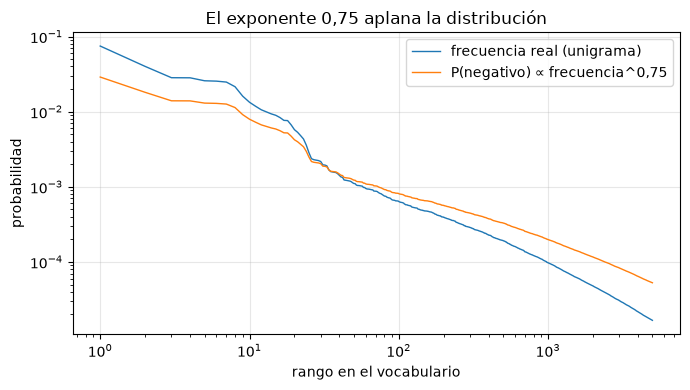

In [9]:
plt.figure(figsize=(7, 4))
rangos = range(1, len(VOCAB))
plt.loglog(rangos, [frecuencias[i] for i in rangos], lw=1, label="frecuencia real (unigrama)")
plt.loglog(rangos, probs[1:].tolist(), lw=1, label="P(negativo) ∝ frecuencia^0,75")
plt.xlabel("rango en el vocabulario")
plt.ylabel("probabilidad")
plt.title("El exponente 0,75 aplana la distribución")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. La loss inicial: un valor conocido

`output_embeddings` se inicializa en **cero**, así que todos los puntajes
iniciales valen 0, la sigmoide da 0,5, y la loss vale exactamente:

$$L_0 = -\ln(0{,}5) - K\ln(0{,}5) = (1 + K)\ln 2$$

Es una verificación de un vistazo de que el modelo arrancó bien.

In [10]:
modelo_nuevo, muestreador = build_model_from_config(CONFIG, VOCAB)
modelo_nuevo.to(DEVICE); muestreador.to(DEVICE)

neg = muestreador.sample(len(target), K)
with torch.no_grad():
    l0 = modelo_nuevo.negative_sampling_loss(context, mask, target, neg)
    p0 = modelo_nuevo.score(modelo_nuevo(context, mask), target)

esperada = (1 + K) * math.log(2)
print(f"puntajes iniciales : todos {float(p0.abs().max()):.1e} (o sea, cero)")
print(f"loss medida        : {l0.item():.6f}")
print(f"loss esperada      : {esperada:.6f}   ((1+{K})·ln2)")
print(f"¿coincide?         : {abs(l0.item() - esperada) < 1e-5}")

puntajes iniciales : todos 0.0e+00 (o sea, cero)
loss medida        : 7.624619
loss esperada      : 7.624619   ((1+10)·ln2)
¿coincide?         : True


## 7. ¿Puede aprender? Test de sobreajuste

La prueba estándar de que una arquitectura está bien conectada: entrenarla
sobre **un solo batch** repetidas veces. Si el modelo y los gradientes están
bien, la loss tiene que desplomarse — el modelo se memoriza ese batch.

Si la loss no bajara, habría un error en el forward, en la loss o en el grafo de
gradientes.

In [11]:
modelo_test, muestreador_test = build_model_from_config(CONFIG, VOCAB)
modelo_test.to(DEVICE); muestreador_test.to(DEVICE)
optimizador = torch.optim.Adam(modelo_test.parameters(), lr=0.01)

neg_fijo = muestreador_test.sample(len(target), K)   # negativos fijos: memorizable
historia = []

for paso in range(300):
    optimizador.zero_grad()
    l = modelo_test.negative_sampling_loss(context, mask, target, neg_fijo)
    l.backward()
    optimizador.step()
    historia.append(l.item())

print(f"loss inicial : {historia[0]:.4f}   (= (1+K)·ln2)")
print(f"loss paso 50 : {historia[50]:.4f}")
print(f"loss paso 150: {historia[150]:.4f}")
print(f"loss final   : {historia[-1]:.4f}")
print(f"reducción    : {100 * (1 - historia[-1] / historia[0]):.1f}%")
print()
print("El modelo memoriza el batch -> el forward, la loss y los gradientes")
print("están bien conectados.")

loss inicial : 7.6246   (= (1+K)·ln2)
loss paso 50 : 0.2053
loss paso 150: 0.0298
loss final   : 0.0204
reducción    : 99.7%

El modelo memoriza el batch -> el forward, la loss y los gradientes
están bien conectados.


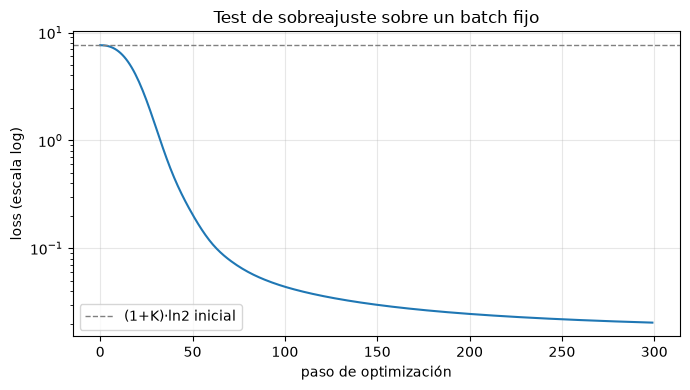

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(historia, lw=1.5)
plt.axhline((1 + K) * math.log(2), ls="--", c="gray", lw=1, label="(1+K)·ln2 inicial")
plt.yscale("log")
plt.xlabel("paso de optimización")
plt.ylabel("loss (escala log)")
plt.title("Test de sobreajuste sobre un batch fijo")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ¿Qué aprendió? Los embeddings de entrada dejaron de ser ruido
antes = build_model_from_config(CONFIG, VOCAB)[0].embeddings
despues = modelo_test.embeddings.detach().cpu()

vistas = torch.unique(torch.cat([context.flatten().cpu(), target.cpu()]))
print(f"palabras que aparecieron en el batch: {len(vistas):,} de {len(VOCAB):,}")
print()
print(f"norma media de los embeddings ANTES  : {antes.norm(dim=1).mean():.4f}")
print(f"norma media de los que SÍ se vieron  : {despues[vistas].norm(dim=1).mean():.4f}")
otras = torch.tensor([i for i in range(len(VOCAB)) if i not in set(vistas.tolist())][:1000])
print(f"norma media de los que NO se vieron  : {despues[otras].norm(dim=1).mean():.4f}")
print()
print("Solo se movieron los embeddings de las palabras presentes en el batch:")
print("los gradientes llegan únicamente a las filas que se usaron.")

palabras que aparecieron en el batch: 461 de 5,000

norma media de los embeddings ANTES  : 0.0408
norma media de los que SÍ se vieron  : 3.6886


norma media de los que NO se vieron  : 0.0409

Solo se movieron los embeddings de las palabras presentes en el batch:
los gradientes llegan únicamente a las filas que se usaron.


## 8. Negative sampling vs softmax completo

La razón de ser del negative sampling: en vez de puntuar contra las 5.000
palabras del vocabulario en cada paso, se puntúa contra la correcta y `K`
sorteadas. Medimos el ahorro real — y el resultado tiene un matiz interesante.

In [14]:
logits = modelo_nuevo.full_softmax_logits(context, mask)
print(f"softmax completo -> logits de forma {tuple(logits.shape)}  "
      f"({logits.numel():,} puntajes por batch)")

n_ns = len(target) * (1 + K)
n_sm = logits.numel()
print(f"negative sampling -> {n_ns:,} puntajes por batch")
print(f"ahorro: {n_sm / n_ns:.0f}x menos puntajes")
print()
print("Cómo escala con el vocabulario (B=512, K=10):")
print(f"{'vocab_size':>11} {'softmax':>14} {'neg. sampling':>15} {'ahorro':>9}")
print("-" * 54)
for V in (5_000, 10_000, 20_000):
    print(f"{V:>11,} {512 * V:>14,} {512 * 11:>15,} {V / 11:>8.0f}x")

softmax completo -> logits de forma (512, 5000)  (2,560,000 puntajes por batch)
negative sampling -> 5,632 puntajes por batch
ahorro: 455x menos puntajes

Cómo escala con el vocabulario (B=512, K=10):
 vocab_size        softmax   neg. sampling    ahorro
------------------------------------------------------
      5,000      2,560,000           5,632      455x
     10,000      5,120,000           5,632      909x
     20,000     10,240,000           5,632     1818x


In [15]:
def cronometrar(fn, repeticiones=100):
    for _ in range(10):          # calentamiento
        fn()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(repeticiones):
        fn()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / repeticiones * 1000


# Comparación JUSTA: ambos caminos hasta la loss y con backward, no solo el
# forward de uno contra la loss del otro.
entropia = torch.nn.CrossEntropyLoss()

print(f"{'vocab':>9} {'neg. sampling':>15} {'softmax':>12} {'relación':>10} "
      f"{'mem. NS':>10} {'mem. SM':>10}")
print("-" * 72)

for V in (5_000, 20_000, 50_000, 200_000):
    m = CBOWModel(V, D, seed=1).to(DEVICE)
    s = NegativeSampler([10] * V).to(DEVICE)
    ctx = torch.randint(0, V, (B, 2 * C), device=DEVICE)
    msk = torch.ones(B, 2 * C, device=DEVICE)
    tgt = torch.randint(0, V, (B,), device=DEVICE)
    ngt = s.sample(B, K)

    def paso_ns():
        m.negative_sampling_loss(ctx, msk, tgt, ngt).backward()

    def paso_sm():
        entropia(m.full_softmax_logits(ctx, msk), tgt).backward()

    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats(); paso_ns()
        mem_ns = torch.cuda.max_memory_allocated() / 1024**2
        torch.cuda.reset_peak_memory_stats(); paso_sm()
        mem_sm = torch.cuda.max_memory_allocated() / 1024**2
    else:
        mem_ns = mem_sm = float("nan")

    t_ns, t_sm = cronometrar(paso_ns), cronometrar(paso_sm)
    marca = "  <- nuestra config" if V == len(VOCAB) else ""
    print(f"{V:>9,} {t_ns:>13.2f}ms {t_sm:>10.2f}ms {t_sm / t_ns:>9.2f}x "
          f"{mem_ns:>8.0f}MB {mem_sm:>8.0f}MB{marca}")

    vocab   neg. sampling      softmax   relación    mem. NS    mem. SM
------------------------------------------------------------------------


    5,000          2.02ms       0.84ms      0.42x       46MB       75MB  <- nuestra config


   20,000          2.06ms       2.10ms      1.02x       57MB      176MB


   50,000          1.91ms       5.29ms      2.77x       81MB      374MB


  200,000          2.39ms      20.46ms      8.56x      196MB     1368MB


**Un resultado honesto que conviene mirar:** con vocabulario 5.000 el softmax
completo es en realidad *más rápido* que el negative sampling en esta GPU. Un
producto `(512, 50) × (50, 5000)` es un matmul que la RTX 3060 resuelve de un
saque, mientras que el negative sampling paga varios lanzamientos de kernel
(dos `gather`, un `bmm`, dos `logsigmoid`).

El negative sampling gana por dos motivos distintos:

1. **Memoria.** El softmax materializa `(B, V)` más su gradiente. A vocabulario
   5.000 son 50 MB; a 200.000, más de 1,3 GB — y esta placa tiene 6 GB. El
   negative sampling se mantiene casi plano porque nunca construye esa matriz.
2. **Escala.** El cruce está cerca de vocabulario 20.000, justo el techo de la
   grilla del proyecto. De ahí para arriba la ventaja crece rápido.

Para la configuración base (5k) el negative sampling no es una optimización de
velocidad: es lo que hace que el mismo código sirva sin cambios cuando el
vocabulario crezca.

In [16]:
# Velocidad de un paso completo de entrenamiento, para dimensionar la Fase 5
modelo_bench, muestreador_bench = build_model_from_config(CONFIG, VOCAB)
modelo_bench.to(DEVICE); muestreador_bench.to(DEVICE)
opt = torch.optim.Adam(modelo_bench.parameters(), lr=CONFIG["learning_rate"])

def paso():
    opt.zero_grad()
    n = muestreador_bench.sample(len(target), K)
    l = modelo_bench.negative_sampling_loss(context, mask, target, n)
    l.backward()
    opt.step()

ms = cronometrar(paso, repeticiones=100)
batches_epoca = 5_061_115 / B

print(f"un paso completo (forward+backward+update): {ms:.3f} ms")
print(f"batches por época del piloto             : {batches_epoca:,.0f}")
print(f"cómputo puro por época                   : {ms * batches_epoca / 1000:.1f} s")
print(f"generación de pares por época (Fase 3)   : ~52 s")
print()
print("El cuello de botella sigue siendo la CPU generando pares, no la GPU.")

un paso completo (forward+backward+update): 3.197 ms
batches por época del piloto             : 9,885
cómputo puro por época                   : 31.6 s
generación de pares por época (Fase 3)   : ~52 s

El cuello de botella sigue siendo la CPU generando pares, no la GPU.


---

# Fase 5 — El loop de entrenamiento

`src/train.py` arma el pipeline completo desde un YAML: vocabulario -> dataset ->
DataLoader -> modelo -> optimizador -> épocas. Cada época hace un pase por el
corpus, evalúa contra un conjunto de validación reservado, guarda un checkpoint
y registra la loss.

## 9. Una corrida corta, para ver la mecánica

Primero un entrenamiento de juguete: 3 épocas de 150 batches cada una. Alcanza
para ver el loop funcionando sin esperar. Se crea un YAML aparte para no pisar
los checkpoints de la corrida real.

In [17]:
import shutil

import yaml

from src.config import checkpoint_dir
from src.train import load_checkpoint, load_history, train

demo = dict(CONFIG)
demo["name"] = "_demo_fase5"
demo["epochs"] = 3
demo["validation_sentences"] = 5_000
DEMO_YAML = ROOT / "configs" / "_demo_fase5.yaml"
DEMO_YAML.write_text(yaml.safe_dump(demo, allow_unicode=True), encoding="utf-8")

resultado = train(DEMO_YAML, max_steps_per_epoch=150, progress=False)

config     : _demo_fase5
dispositivo: cuda | workers: 0
modelo     : CBOWModel(vocab_size=5000, embedding_dim=50, parámetros=500,000)
validación : 5,000 oraciones reservadas
epocas     : 0 a 2



época   0 | train 5.3990 | val 3.4343 |     76,800 pares |    2.1s |    36,356 pares/s | lr 3.00e-03


época   1 | train 3.3222 | val 3.2934 |     76,800 pares |    2.2s |    34,712 pares/s | lr 2.00e-03


época   2 | train 3.2547 | val 3.2725 |     76,800 pares |    2.5s |    30,959 pares/s | lr 1.00e-03

artefactos en: C:\Users\Carlo\Documents\Maestria\Proyecto_T\projects_claude\proyecto_cbow\checkpoints\_demo_fase5


Se ve el patrón esperado: la loss arranca cerca de `(1+K)·ln2 = 7,62` y baja
rápido, y el learning rate decae linealmente época a época.

## 10. Qué guarda un checkpoint

Cada época deja un `.pt` con todo lo necesario para retomar. Guardar el estado
del **optimizador** es lo que suele olvidarse: Adam mantiene medias móviles de
los gradientes, y reanudar sin ellas equivale a reiniciarlo a mitad de camino.

In [18]:
carpeta = checkpoint_dir(demo)
print("archivos generados:")
for archivo in sorted(carpeta.iterdir()):
    print(f"  {archivo.name:<16} {archivo.stat().st_size / 1024:>8,.1f} KB")

print()
checkpoint = load_checkpoint(carpeta / "last.pt")
print("contenido del checkpoint:")
for clave, valor in checkpoint.items():
    if clave in ("model_state", "optimizer_state"):
        print(f"  {clave:<16} {len(valor)} entradas")
    elif clave == "history":
        print(f"  {clave:<16} {len(valor)} épocas")
    elif clave == "config":
        print(f"  {clave:<16} la configuración completa de la corrida")
    else:
        print(f"  {clave:<16} {valor}")

archivos generados:
  best.pt           5,863.2 KB
  epoch_00.pt       5,863.5 KB
  epoch_01.pt       5,863.6 KB
  epoch_02.pt       5,863.6 KB
  history.json          1.2 KB
  last.pt           5,863.2 KB

contenido del checkpoint:
  epoch            2
  model_state      2 entradas
  optimizer_state  2 entradas
  history          3 épocas
  config           la configuración completa de la corrida
  vocab_size       5000
  embedding_dim    50


In [19]:
# Retomar: continúa en la época siguiente, con el historial intacto
demo["epochs"] = 5
DEMO_YAML.write_text(yaml.safe_dump(demo, allow_unicode=True), encoding="utf-8")

continuado = train(DEMO_YAML, max_steps_per_epoch=150, resume=True, progress=False)

print()
print("historial completo tras retomar:")
for e in continuado["epochs"]:
    print(f"  época {e['epoch']}: train {e['train_loss']:.4f}")
print()
print("Las 3 primeras épocas vienen del checkpoint; las 2 últimas son nuevas.")

retomando desde la época 3 (last.pt)
config     : _demo_fase5
dispositivo: cuda | workers: 0
modelo     : CBOWModel(vocab_size=5000, embedding_dim=50, parámetros=500,000)
validación : 5,000 oraciones reservadas
epocas     : 3 a 4



época   3 | train 3.2375 | val 3.2587 |     76,800 pares |    2.6s |    29,702 pares/s | lr 1.20e-03


época   4 | train 3.2260 | val 3.2563 |     76,800 pares |    2.6s |    29,660 pares/s | lr 6.00e-04

artefactos en: C:\Users\Carlo\Documents\Maestria\Proyecto_T\projects_claude\proyecto_cbow\checkpoints\_demo_fase5

historial completo tras retomar:
  época 0: train 5.3990
  época 1: train 3.3222
  época 2: train 3.2547
  época 3: train 3.2375
  época 4: train 3.2260

Las 3 primeras épocas vienen del checkpoint; las 2 últimas son nuevas.


In [20]:
# Limpieza de la corrida de demostración
shutil.rmtree(carpeta)
DEMO_YAML.unlink()
print("demostración eliminada")

demostración eliminada


## 11. La corrida real: 15 épocas sobre 2M de oraciones

Esta es la corrida que importa, lanzada desde la línea de comandos:

```bash
python -m src.train --config configs/piloto_5k_50_2.yaml
```

Leemos su `history.json`, que se guarda aparte de los checkpoints justamente
para poder analizar las curvas sin cargar ningún modelo.

In [21]:
historia = load_history(CONFIG)

print(f"{'época':>6} {'train':>8} {'val':>8} {'pares':>12} {'seg':>8} {'lr':>10}")
print("-" * 58)
for e in historia:
    print(f"{e['epoch']:>6} {e['train_loss']:>8.4f} {e['val_loss']:>8.4f} "
          f"{e['pairs']:>12,} {e['seconds']:>8.1f} {e['learning_rate']:>10.2e}")

total = sum(e["seconds"] for e in historia)
print()
print(f"tiempo total     : {total / 60:.1f} min")
print(f"pares procesados : {sum(e['pairs'] for e in historia):,}")
print(f"loss inicial     : {(1 + K) * math.log(2):.4f}  (antes del primer paso)")
print(f"loss final       : train {historia[-1]['train_loss']:.4f} | "
      f"val {historia[-1]['val_loss']:.4f}")

 época    train      val        pares      seg         lr
----------------------------------------------------------
     0   2.9664   2.7528    5,012,731    154.9   3.00e-03
     1   2.7274   2.7024    5,007,587    157.1   2.80e-03
     2   2.6990   2.6896    5,011,379    154.6   2.60e-03
     3   2.6882   2.6833    5,008,931    166.0   2.40e-03
     4   2.6811   2.6782    5,013,716    156.7   2.20e-03
     5   2.6747   2.6736    5,010,544    154.3   2.00e-03
     6   2.6704   2.6697    5,012,108    155.4   1.80e-03
     7   2.6649   2.6655    5,009,521    154.6   1.60e-03
     8   2.6603   2.6625    5,009,567   1151.1   1.40e-03
     9   2.6563   2.6578    5,010,661    154.9   1.20e-03
    10   2.6523   2.6540    5,010,729    155.9   1.00e-03
    11   2.6479   2.6518    5,012,053    156.8   8.00e-04
    12   2.6432   2.6479    5,011,406    231.9   6.00e-04
    13   2.6405   2.6453    5,007,032    156.0   4.00e-04
    14   2.6358   2.6430    5,009,035    156.4   2.00e-04

tiempo total

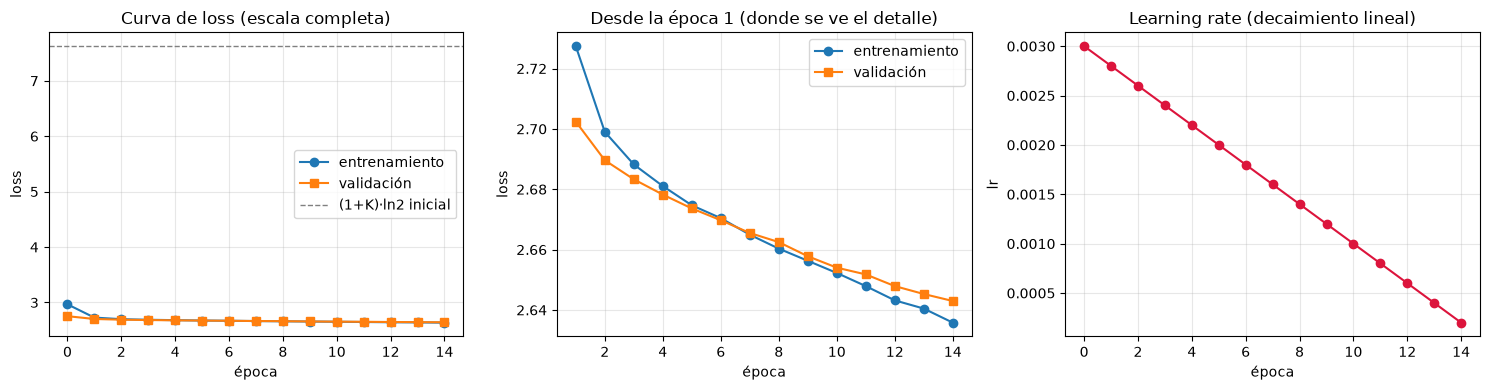

In [22]:
epocas = [e["epoch"] for e in historia]
train_loss = [e["train_loss"] for e in historia]
val_loss = [e["val_loss"] for e in historia]
lrs = [e["learning_rate"] for e in historia]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epocas, train_loss, "o-", label="entrenamiento", lw=1.5)
axes[0].plot(epocas, val_loss, "s-", label="validación", lw=1.5)
axes[0].axhline((1 + K) * math.log(2), ls="--", c="gray", lw=1, label="(1+K)·ln2 inicial")
axes[0].set_title("Curva de loss (escala completa)")
axes[0].set_xlabel("época"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epocas[1:], train_loss[1:], "o-", label="entrenamiento", lw=1.5)
axes[1].plot(epocas[1:], val_loss[1:], "s-", label="validación", lw=1.5)
axes[1].set_title("Desde la época 1 (donde se ve el detalle)")
axes[1].set_xlabel("época"); axes[1].set_ylabel("loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epocas, lrs, "o-", c="crimson", lw=1.5)
axes[2].set_title("Learning rate (decaimiento lineal)")
axes[2].set_xlabel("época"); axes[2].set_ylabel("lr")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Tres cosas que se leen en las curvas:

1. **Casi todo el aprendizaje ocurre en la primera época.** De 7,62 a 2,97. Las
   14 restantes van de 2,97 a 2,64 — refinamiento, no aprendizaje grueso.
2. **No hay sobreajuste.** Las curvas de entrenamiento y validación van pegadas
   hasta el final (2,636 vs 2,643). Con 500.000 parámetros y 5 millones de pares
   por época, el modelo no tiene margen para memorizar.
3. **La mejora se agota.** Entre las épocas 10 y 14 la validación baja 0,011. Si
   hubiera que recortar el presupuesto, 8-10 épocas dan casi lo mismo.

> El pico de tiempo de la época 8 (1.151 s contra ~155 s del resto) es
> contención de la máquina durante la corrida, no algo del modelo.

## 12. ¿Aprendió algo? La prueba de los vecinos

Que la loss baje no prueba que los embeddings sirvan. La prueba real es
geométrica: palabras parecidas deberían quedar cerca. Esto adelanta la Fase 6,
pero es la validación que cierra el entrenamiento.

In [23]:
entrenado, _ = build_model_from_config(CONFIG, VOCAB)
checkpoint = load_checkpoint(checkpoint_dir(CONFIG) / "best.pt", entrenado)
print(f"cargado el checkpoint de la época {checkpoint['epoch']}")
print()

# Normalizar para que el producto punto sea la similitud coseno
E = torch.nn.functional.normalize(entrenado.embeddings.detach(), dim=1)

def vecinos(palabra, k=6):
    if palabra not in VOCAB:
        return f"{palabra}: fuera del vocabulario"
    indice = VOCAB.index(palabra)
    similitud = E @ E[indice]
    similitud[indice] = -2                      # que no se devuelva a sí misma
    return ", ".join(VOCAB.word(i) for i in similitud.topk(k).indices.tolist())

for palabra in ["lunes", "febrero", "tres", "rojo", "presidente",
                "ciudad", "argentina", "mujer", "empresa", "dijo"]:
    print(f"  {palabra:<12} -> {vecinos(palabra)}")

cargado el checkpoint de la época 14

  lunes        -> viernes, jueves, sábado, horario, horas, domingo
  febrero      -> marzo, abril, octubre, mayo, julio, junio
  tres         -> cuatro, dos, cinco, siete, ocho, seis
  rojo         -> azul, blanco, negro, amarillo, color, verde
  presidente   -> presidenta, vicepresidente, presidencia, embajador, comisario, señor
  ciudad       -> villa, barrio, colonia, plaza, provincia, ubicada
  argentina    -> argentino, republica, chile, paraguay, mendoza, uruguay
  mujer        -> niña, infancia, niño, hermosa, vida, amiga
  empresa      -> empleador, actividad, empresario, sindical, trabajadores, anonima
  dijo         -> decía, sabía, dijeron, dije, llamó, dijiste


**Esto es lo que valida toda la cadena.** Sin haberle dicho nunca qué es un día
de la semana, un color o un mes, el modelo agrupó:

* los días entre sí (`lunes` -> viernes, jueves, sábado, domingo)
* los meses entre sí (`febrero` -> marzo, abril, octubre, mayo)
* los números entre sí (`tres` -> cuatro, dos, cinco, siete)
* los colores entre sí (`rojo` -> azul, blanco, negro, amarillo)
* los países vecinos (`argentina` -> chile, paraguay, uruguay)
* las formas verbales (`dijo` -> decía, dijeron, dije)

Todo eso salió de una única señal: qué palabras aparecen cerca de cuáles.

## Conclusiones de las Fases 4 y 5

- La arquitectura está completa: dos matrices de embeddings, promedio
  enmascarado del contexto y negative sampling en la salida.
- Las dimensiones se verificaron paso a paso: `(B, 2C)` → `(B, 2C, D)` →
  `(B, D)` → puntajes `(B,)` y `(B, K)` → loss escalar.
- El promedio enmascarado coincide con la cuenta hecha a mano, y se midió qué
  pasaría sin la máscara (el vector sale escalado y contaminado con el relleno).
- El muestreador reproduce la distribución unigrama^0,75 con error < 1e-4 y
  nunca sortea `<UNK>`.
- La loss inicial vale exactamente `(1+K)·ln 2`, como corresponde a la
  inicialización en cero de la matriz de salida.
- El test de sobreajuste confirma que el modelo aprende: la loss se desploma
  sobre un batch fijo, y solo se mueven los embeddings de las palabras vistas.

**Fase 5:**

- El loop entrena, evalúa, guarda checkpoints y registra las curvas; `--resume`
  retoma exactamente donde se cortó, con el estado del optimizador incluido.
- La corrida piloto (15 épocas, 75 millones de pares) llevó la loss de 7,62 a
  2,64 sin señales de sobreajuste.
- Los vecinos cercanos confirman que los embeddings capturan estructura real del
  español, no solo que la loss bajó.

**Siguiente paso:** Fase 6 — `src/evaluate.py` y `src/export.py` (vecinos
cercanos, analogías, visualización y exportación a formato Word2Vec).